# VAE Learned Queries Evaluation

Evaluate reconstruction quality of the new VAE with learned decoder queries.

In [30]:
import os, sys
sys.path.insert(0, os.path.expandvars("$GWM_PATH"))
import torch, numpy as np, matplotlib.pyplot as plt, json
from pytorch3d.ops import sample_farthest_points as fps
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

GWM_PATH = os.environ["GWM_PATH"]
SH_C0 = 0.28209479177387814
PC_SIZE = 2048

In [31]:
# Load Splatt3r + new VAE
from gaussianwm.processor.regressor import Splatt3rRegressor
from gaussianwm.encoder.models_ae import create_autoencoder

splatt3r = Splatt3rRegressor().cuda().eval()

NEW_VAE_CKPT = f"{GWM_PATH}/logs/vae_learned_q_m512/checkpoint-10.pth"
vae = create_autoencoder(
    depth=4, dim=64, M=512, latent_dim=64, output_dim=14, N=PC_SIZE,
    deterministic=False, use_learned_queries=True
).cuda()
ckpt = torch.load(NEW_VAE_CKPT, map_location="cuda", weights_only=False)
vae.load_state_dict(ckpt['model'])
vae.eval()
print(f"VAE loaded from {NEW_VAE_CKPT}")

/home/frankcholula/Workspace/gaussianwm/gaussianwm/processor/regressor.py:164: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(pretrained_model_name_or

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [on]


/home/frankcholula/Workspace/gaussianwm/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/frankcholula/Workspace/gaussianwm/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /home/frankcholula/Workspace/gaussianwm/.venv/lib/python3.10/site-packages/lpips/weights/v0.1/alex.pth


/home/frankcholula/Workspace/gaussianwm/.venv/lib/python3.10/site-packages/lpips/lpips.py:107: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(

🔥🔥🔥 Splatt3r Model loaded from /home/frankcholula/Workspace/gaussianwm/third_party/splatt3r/checkpoints/splatt3r_v1.0/epoch=19-step=1200.ckpt
VAE loaded from /home/frankcholula/Workspace/gaussianwm/logs/vae_learned_q_m512/checkpoint-10.pth


In [32]:
# Load DROID-100 test frames
import tensorflow_datasets as tfds
from PIL import Image as PILImage

ds = tfds.load("droid_100", data_dir=f"{GWM_PATH}/data/", split="train", with_info=False)
ep = next(iter(ds))
steps = list(ep["steps"])
n_steps = len(steps)

n_frames = 8
test_indices = [int(i * (n_steps - 1) / (n_frames - 1)) for i in range(n_frames)]
test_imgs = []
for i in test_indices:
    img = PILImage.fromarray(steps[i]["observation"]["exterior_image_1_left"].numpy())
    test_imgs.append(np.array(img.resize((128, 128), PILImage.BILINEAR)))

print(f"Episode: {n_steps} frames, selected indices: {test_indices}")

Episode: 166 frames, selected indices: [0, 23, 47, 70, 94, 117, 141, 165]


In [33]:
# Helpers
def img_to_points(img_np):
    """[H,W,3] uint8 image → (full 16384, downsampled 2048) point clouds."""
    img_tensor = torch.from_numpy(img_np).permute(2, 0, 1).float().unsqueeze(0).cuda()
    with torch.no_grad():
        points_full, _ = splatt3r.forward_tensor(img_tensor)
    points_pp = points_full.clone()
    points_pp[..., -4:-1] = (0.5 + SH_C0 * points_pp[..., -4:-1]) / 255.0
    points_ds, _ = fps(points_pp, K=PC_SIZE)
    return points_pp, points_ds

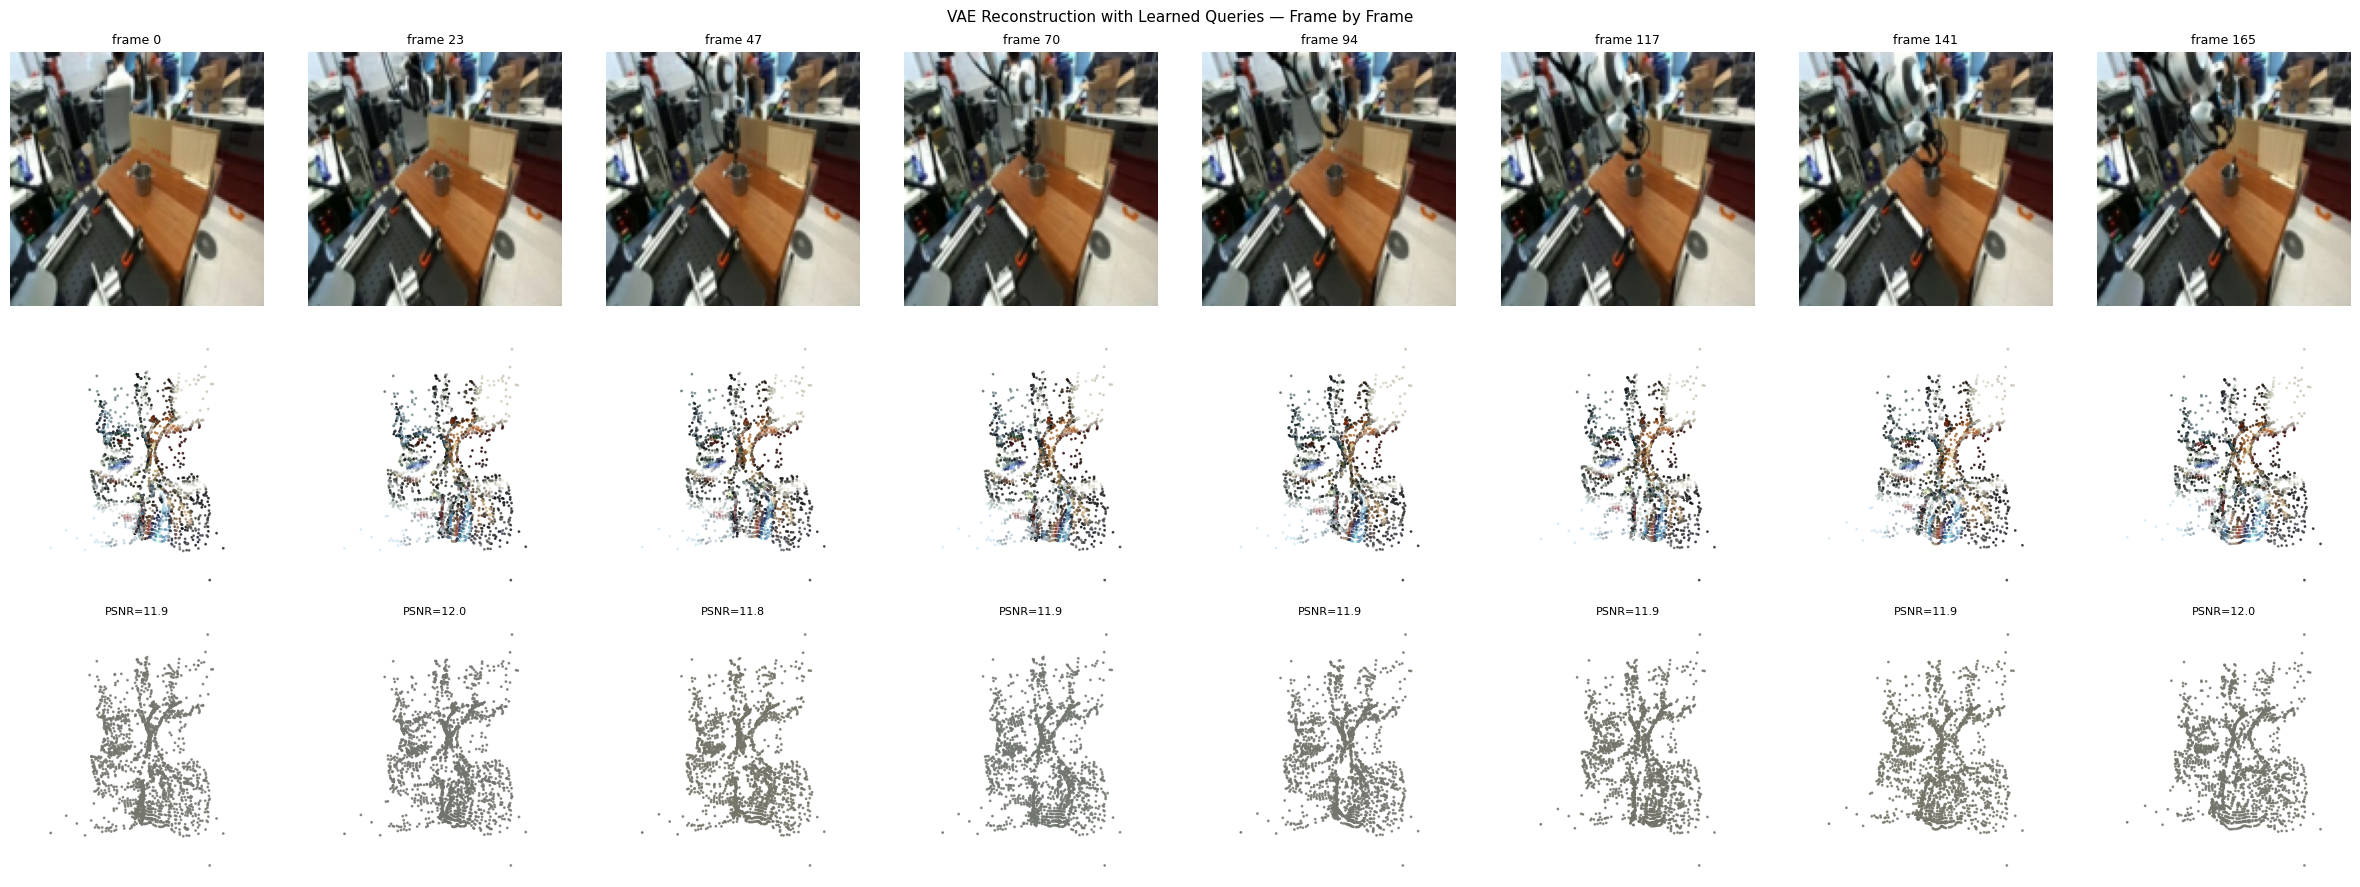


Per-frame PSNR: 11.9, 12.0, 11.8, 11.9, 11.9, 11.9, 11.9, 12.0
Mean PSNR: 11.93 ± 0.06 dB
Mean SSIM: 0.0171 ± 0.0002


In [34]:
# Frame-by-frame VAE reconstruction
# Encode → decode with learned queries (identical at train & inference)
frame_psnrs, frame_ssims = [], []
gt_rgbs, recon_rgbs, gt_pts_all, recon_pts_all = [], [], [], []

for col, idx in enumerate(test_indices):
    points_full, points_ds = img_to_points(test_imgs[col])

    with torch.no_grad():
        kl, z = vae.encode(points_ds)
        recon = vae.decode(z)

    gt_sh = points_ds[0, :, 10:13].clamp(0, 1).cpu().numpy()
    recon_sh = recon[0, :, 10:13].clamp(0, 1).cpu().numpy()
    p = psnr(gt_sh, recon_sh, data_range=1.0)
    s = ssim(gt_sh, recon_sh, data_range=1.0, channel_axis=1)
    frame_psnrs.append(p); frame_ssims.append(s)

    gt_pts_all.append(points_ds[0].cpu().numpy())
    recon_pts_all.append(recon[0].cpu().numpy())

# Visualize: 3 rows x n_frames cols
fig, axes = plt.subplots(3, n_frames, figsize=(n_frames * 3, 9))

for col in range(n_frames):
    idx = test_indices[col]
    gt_pts = gt_pts_all[col]
    recon_pts = recon_pts_all[col]

    # Row 0: GT RGB image
    axes[0, col].imshow(test_imgs[col])
    axes[0, col].set_title(f"frame {idx}", fontsize=9)
    axes[0, col].axis("off")

    # Row 1: GT point cloud colors (scatter)
    axes[1, col].scatter(gt_pts[:, 0], gt_pts[:, 1],
                         c=np.clip(gt_pts[:, 10:13], 0, 1), s=1, alpha=0.8)
    axes[1, col].set_aspect('equal'); axes[1, col].axis("off")

    # Row 2: VAE reconstruction colors (scatter, same GT positions for fair comparison)
    axes[2, col].scatter(gt_pts[:, 0], gt_pts[:, 1],
                         c=np.clip(recon_pts[:, 10:13], 0, 1), s=1, alpha=0.8)
    axes[2, col].set_title(f"PSNR={frame_psnrs[col]:.1f}", fontsize=8)
    axes[2, col].set_aspect('equal'); axes[2, col].axis("off")

axes[0, 0].set_ylabel("GT RGB", fontsize=9)
axes[1, 0].set_ylabel("GT SH colors\n(2048 pts)", fontsize=9)
axes[2, 0].set_ylabel("VAE recon\n(learned q)", fontsize=9)
plt.suptitle("VAE Reconstruction with Learned Queries — Frame by Frame", fontsize=11)
plt.tight_layout(); plt.show()

print(f"\nPer-frame PSNR: {', '.join(f'{p:.1f}' for p in frame_psnrs)}")
print(f"Mean PSNR: {np.mean(frame_psnrs):.2f} ± {np.std(frame_psnrs):.2f} dB")
print(f"Mean SSIM: {np.mean(frame_ssims):.4f} ± {np.std(frame_ssims):.4f}")

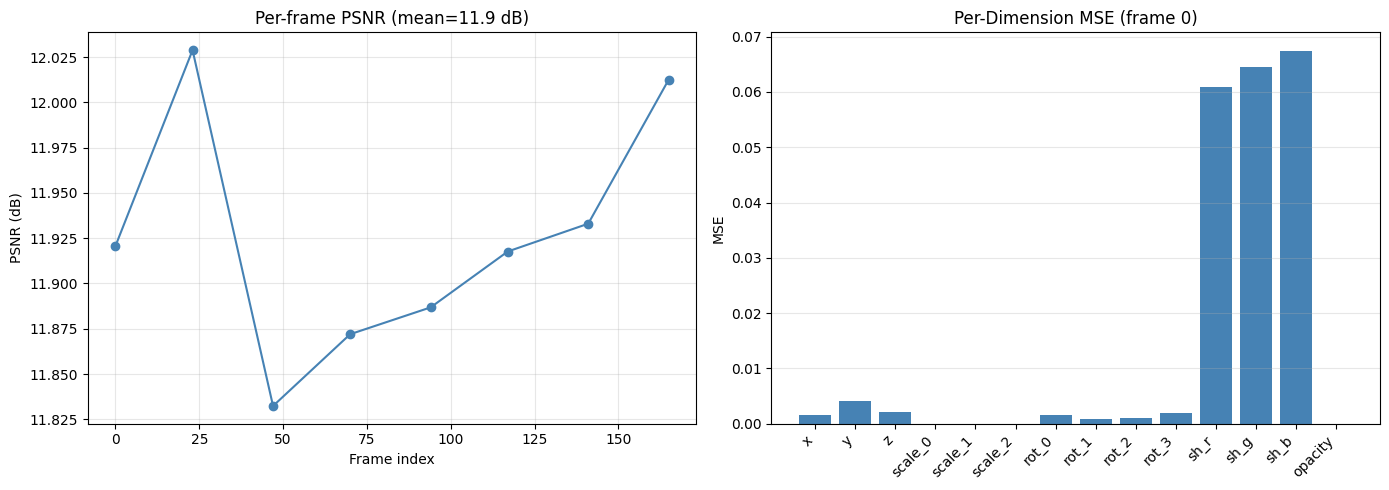


       Dim           MSE
-------------------------
         x      0.001534
         y      0.004087
         z      0.002073
   scale_0      0.000014
   scale_1      0.000004
   scale_2      0.000002
     rot_0      0.001629
     rot_1      0.000882
     rot_2      0.001081
     rot_3      0.001941
      sh_r      0.060847
      sh_g      0.064426
      sh_b      0.067404
   opacity      0.000011
   OVERALL      0.014710


In [35]:
# PSNR across frames plot + per-dimension MSE
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: PSNR per frame
ax1.plot(test_indices, frame_psnrs, 'o-', color='steelblue', markersize=6)
ax1.set_xlabel("Frame index"); ax1.set_ylabel("PSNR (dB)")
ax1.set_title(f"Per-frame PSNR (mean={np.mean(frame_psnrs):.1f} dB)")
ax1.grid(True, alpha=0.3)

# Right: per-dimension MSE (first frame)
dim_labels = ['x', 'y', 'z', 'scale_0', 'scale_1', 'scale_2',
              'rot_0', 'rot_1', 'rot_2', 'rot_3', 'sh_r', 'sh_g', 'sh_b', 'opacity']
points_full, points_ds = img_to_points(test_imgs[0])
with torch.no_grad():
    recon = vae(points_ds)['logits']
per_dim = ((recon - points_ds) ** 2).mean(dim=(0, 1)).cpu().numpy()

ax2.bar(range(14), per_dim, color='steelblue')
ax2.set_xticks(range(14)); ax2.set_xticklabels(dim_labels, rotation=45, ha='right')
ax2.set_ylabel('MSE'); ax2.set_title('Per-Dimension MSE (frame 0)')
ax2.grid(True, axis='y', alpha=0.3)

plt.tight_layout(); plt.show()

print(f"\n{'Dim':>10s}  {'MSE':>12s}")
print('-' * 25)
for d, label in enumerate(dim_labels):
    print(f'{label:>10s}  {per_dim[d]:>12.6f}')
print(f"{'OVERALL':>10s}  {per_dim.mean():>12.6f}")

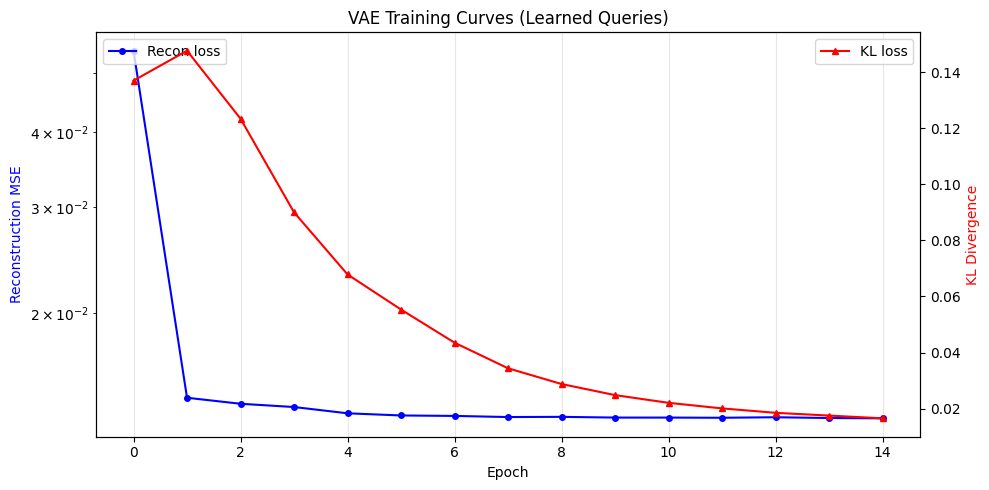

In [36]:
# Training curves
log = [json.loads(l) for l in open(f"{GWM_PATH}/logs/vae_learned_q_m512/log.txt")]

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot([d['epoch'] for d in log], [d['train_loss_vol'] for d in log],
         'b-o', markersize=4, label='Recon loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Reconstruction MSE', color='b')
ax1.set_yscale('log'); ax1.legend(loc='upper left'); ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot([d['epoch'] for d in log], [d['train_loss_kl'] for d in log],
         'r-^', markersize=4, label='KL loss')
ax2.set_ylabel('KL Divergence', color='r'); ax2.legend(loc='upper right')

plt.title('VAE Training Curves (Learned Queries)')
plt.tight_layout(); plt.show()